In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


  Index        Date        Open        High         Low       Close  \
0   NYA  1965-12-31  528.690002  528.690002  528.690002  528.690002   
1   NYA  1966-01-03  527.210022  527.210022  527.210022  527.210022   
2   NYA  1966-01-04  527.840027  527.840027  527.840027  527.840027   
3   NYA  1966-01-05  531.119995  531.119995  531.119995  531.119995   
4   NYA  1966-01-06  532.070007  532.070007  532.070007  532.070007   

    Adj Close  Volume  
0  528.690002     0.0  
1  527.210022     0.0  
2  527.840027     0.0  
3  531.119995     0.0  
4  532.070007     0.0  
(110253, 8)

PART 1: BINARY LOGISTIC REGRESSION
---------------------------------------------
Accuracy: 0.8611400843499161
              precision    recall  f1-score   support

  Price Down       0.84      0.94      0.89     12952
    Price Up       0.90      0.74      0.82      9099

    accuracy                           0.86     22051
   macro avg       0.87      0.84      0.85     22051
weighted avg       0.87      0.86 

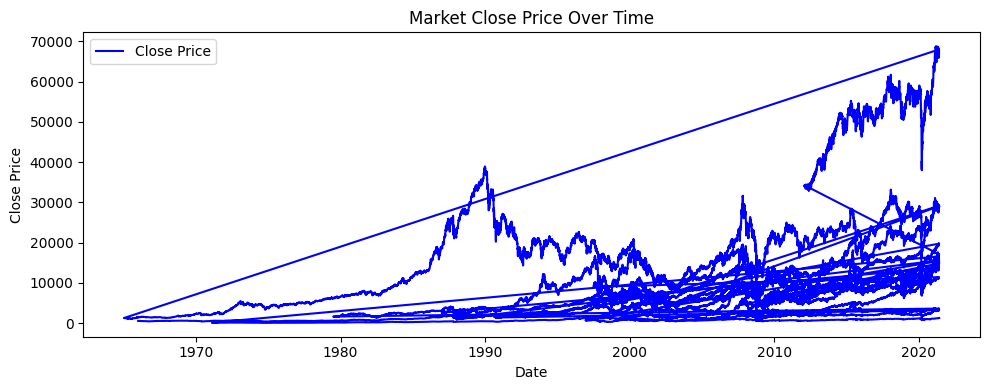

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---------------------------------------------------------
# STEP 1: Load and Prepare the Data
# ---------------------------------------------------------
df = pd.read_csv('/content/drive/MyDrive/colab/indexData.csv')

# Drop rows with any NaN values to prevent model training errors
df = df.dropna()

print(df.head())
print(df.shape)

# Create a target column: 1 if Close price is greater than Open price, else 0
df['Target'] = (df['Close'] > df['Open']).astype(int)

# ===========================================================
# PART 1: BINARY LOGISTIC REGRESSION
# Features: Open, High, Low, Volume -> Target: Price Direction (0 = Down, 1 = Up)
# ===========================================================
print("\nPART 1: BINARY LOGISTIC REGRESSION")
print("-" * 45)

X = df[['Open', 'High', 'Low', 'Volume']]  # features
y = df['Target']                            # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

binary_model = LogisticRegression()
binary_model.fit(X_train, y_train)

y_pred = binary_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Price Down", "Price Up"]))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# Simple plot: Actual Close prices over time
plt.figure(figsize=(10, 4))
plt.plot(pd.to_datetime(df['Date']), df['Close'], color="blue", label="Close Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Market Close Price Over Time")
plt.legend()
plt.tight_layout()
plt.savefig("market_close_plot.png")
print("\nSaved plot -> market_close_plot.png")